# Data Cleaning

In [1]:
# Import pandas library for data manipulation and analysis
import pandas as pd

# Import gdown library for downloading files from Google Drive (if needed)
import gdown

# Import numpy library for scientific computing and array manipulation
import numpy as np

# Import datetime library for working with dates and times
from datetime import datetime

# Import matplotlib.pyplot for creating visualizations (plots)
import matplotlib.pyplot as plt

# Import seaborn library for creating statistical data visualizations
import seaborn as sns

# Import warnings library to suppress warnings (use with caution)
import warnings
warnings.filterwarnings("ignore")  # **Caution:** May hide important warnings

# Set pandas display options to show all columns in the DataFrame (might be inconvenient for large datasets)
pd.set_option('display.max_columns', None)

# Import libraries from scipy.stats for statistical tests
from scipy.stats import shapiro, skew

# Import libraries from sklearn.preprocessing for data scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Import libraries from sklearn.cluster for clustering algorithms
from sklearn import cluster

# Untuk melakukan analisis siluet untuk k-means clustering
from yellowbrick.cluster import SilhouetteVisualizer

plt.rcParams['axes.grid'] = False

In [2]:
# Input Data

potter_url1 = 'https://drive.google.com/file/d/1hdN3VmOTw0oFe0vKY_mwBW1eehpwM4f4/view?usp=drive_link'

Potter1 = 'https://drive.google.com/uc?id='+ potter_url1.split('/')[-2]

potter_url2 = 'https://drive.google.com/file/d/1utxrVezuezcJVwFEseBYR5D1nac5GYYE/view?usp=drive_link'

Potter2 = 'https://drive.google.com/uc?id='+ potter_url2.split('/')[-2]

acc_rec_df = pd.read_csv(Potter1)

cc_rec_df = pd.read_csv(Potter2)

acc_rec_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1


In [3]:
#Data Checking
acc_rec_df.info()

cc_rec_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

On the column Occupation Type there is 134000 missing data compared to other column so we can remove it later so it doesn't effect our model later

In [ ]:
# Checking for duplicate
print(acc_rec_df['ID'].nunique())

print(cc_rec_df['ID'].nunique())

438510
45985


Based on the result the account record have some duplicate id and on cc records have repeating ids based on diffrent months and diffrent values

In [ ]:
# to see how many id match between 2 data sets
len(set(cc_rec_df['ID']).intersection(set(acc_rec_df['ID'])))

36457

<Axes: >

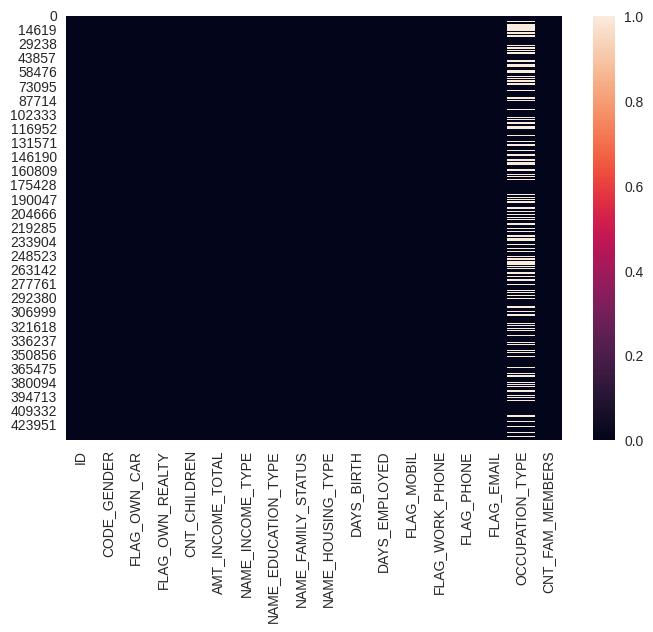

In [ ]:
# just to make sure we dont have any nulls in both data sets other than the ones that have been identified
sns.heatmap(acc_rec_df.isnull())
# As identified before there is many null data in occupation_type column

<Axes: >

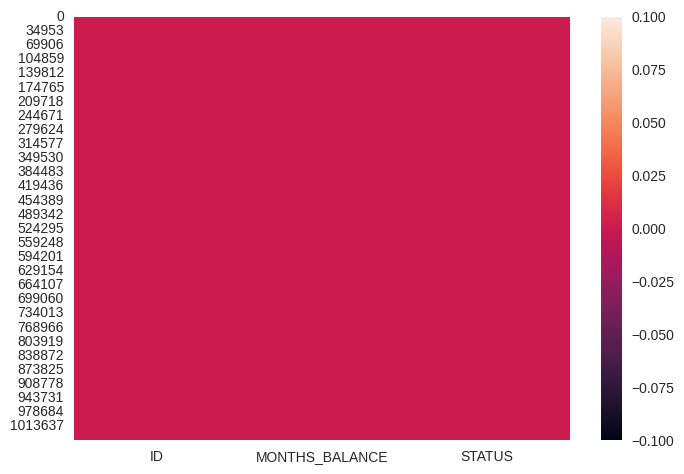

In [ ]:
sns.heatmap(cc_rec_df.isnull())
# All good on this data set

In [ ]:
# Removing duplicate data in account record df and occupation_type column
acc_rec_df = acc_rec_df.drop_duplicates('ID', keep='last')
acc_rec_df.drop('OCCUPATION_TYPE', axis=1, inplace=True)

In [ ]:
# filtering non interger type column and do encoding so that those column of data can be processed in ML model
object_ty = pd.DataFrame(acc_rec_df.dtypes =='object').reset_index()
object_type = object_ty[object_ty[0] == True]['index']
object_type

# Checking for the column content
o1 = acc_rec_df[object_type]['CODE_GENDER'].value_counts()
o2 = acc_rec_df[object_type]['FLAG_OWN_CAR'].value_counts()
o3 = acc_rec_df[object_type]['FLAG_OWN_REALTY'].value_counts()
o4 = acc_rec_df[object_type]['NAME_INCOME_TYPE'].value_counts()
o5 = acc_rec_df[object_type]['NAME_EDUCATION_TYPE'].value_counts()
o6 = acc_rec_df[object_type]['NAME_FAMILY_STATUS'].value_counts()
o7 = acc_rec_df[object_type]['NAME_HOUSING_TYPE'].value_counts()

print( o1,"\n",o2,'\n', o3, '\n', o4, '\n', o5, '\n', o6, '\n', o7)

CODE_GENDER
F    294412
M    144098
Name: count, dtype: int64 
 FLAG_OWN_CAR
N    275428
Y    163082
Name: count, dtype: int64 
 FLAG_OWN_REALTY
Y    304043
N    134467
Name: count, dtype: int64 
 NAME_INCOME_TYPE
Working                 226087
Commercial associate    100739
Pensioner                75483
State servant            36184
Student                     17
Name: count, dtype: int64 
 NAME_EDUCATION_TYPE
Secondary / secondary special    301789
Higher education                 117509
Incomplete higher                 14849
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64 
 NAME_FAMILY_STATUS
Married                 299798
Single / not married     55268
Civil marriage           36524
Separated                27249
Widow                    19671
Name: count, dtype: int64 
 NAME_HOUSING_TYPE
House / apartment      393788
With parents            19074
Municipal apartment     14213
Rented apartment         5974
Office apartmen

In [ ]:
# Create filtered data if it is numeric.
num_type = pd.DataFrame(acc_rec_df.dtypes !='object').reset_index().rename(columns =  {0:'yes/no'})
num_type = num_type[num_type['yes/no'] ==True]['index']

In [ ]:
# Encoding The data
from sklearn.preprocessing import LabelEncoder
encoding = LabelEncoder()
for x in acc_rec_df:
    if acc_rec_df[x].dtypes=='object':
        acc_rec_df[x] = encoding.fit_transform(acc_rec_df[x])

In [ ]:
acc_rec_df.head()

o1 = acc_rec_df[object_type]['CODE_GENDER'].value_counts()
o2 = acc_rec_df[object_type]['FLAG_OWN_CAR'].value_counts()
o3 = acc_rec_df[object_type]['FLAG_OWN_REALTY'].value_counts()
o4 = acc_rec_df[object_type]['NAME_INCOME_TYPE'].value_counts()
o5 = acc_rec_df[object_type]['NAME_EDUCATION_TYPE'].value_counts()
o6 = acc_rec_df[object_type]['NAME_FAMILY_STATUS'].value_counts()
o7 = acc_rec_df[object_type]['NAME_HOUSING_TYPE'].value_counts()

print( o1,"\n",o2,'\n', o3, '\n', o4, '\n', o5, '\n', o6, '\n', o7)

CODE_GENDER
0    294412
1    144098
Name: count, dtype: int64 
 FLAG_OWN_CAR
0    275428
1    163082
Name: count, dtype: int64 
 FLAG_OWN_REALTY
1    304043
0    134467
Name: count, dtype: int64 
 NAME_INCOME_TYPE
4    226087
0    100739
1     75483
2     36184
3        17
Name: count, dtype: int64 
 NAME_EDUCATION_TYPE
4    301789
1    117509
2     14849
3      4051
0       312
Name: count, dtype: int64 
 NAME_FAMILY_STATUS
1    299798
3     55268
0     36524
2     27249
4     19671
Name: count, dtype: int64 
 NAME_HOUSING_TYPE
1    393788
5     19074
2     14213
4      5974
3      3922
0      1539
Name: count, dtype: int64


<Axes: xlabel='ID', ylabel='CNT_FAM_MEMBERS'>

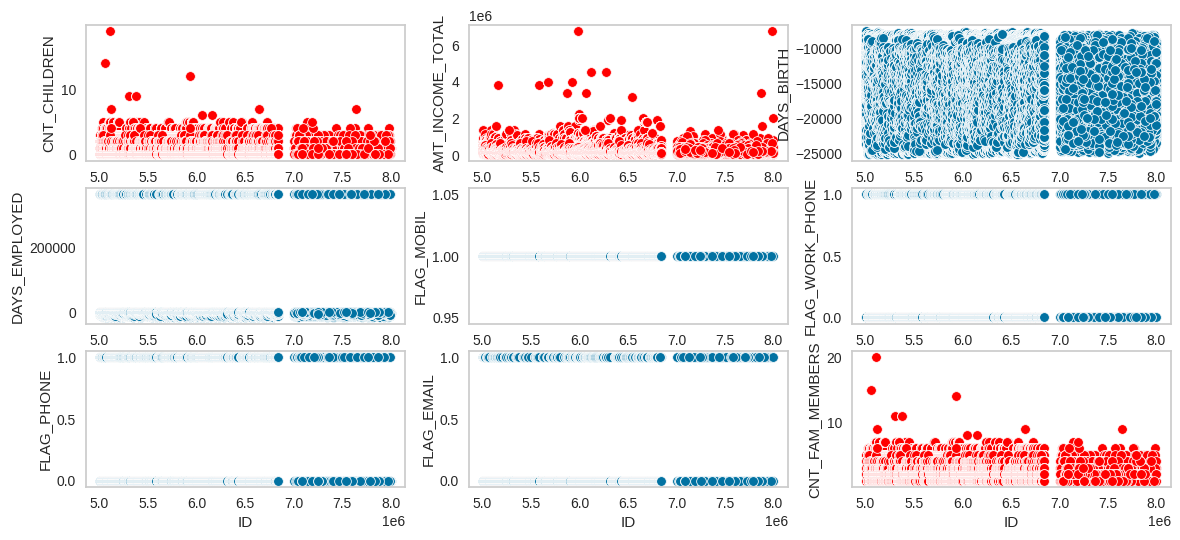

In [ ]:
# Checking for outlier in numeric data set
fig, ax= plt.subplots(nrows= 3, ncols = 3, figsize= (14,6))

sns.scatterplot(x='ID', y='CNT_CHILDREN', data=acc_rec_df, ax=ax[0][0], color= 'red')
sns.scatterplot(x='ID', y='AMT_INCOME_TOTAL', data=acc_rec_df, ax=ax[0][1], color='red')
sns.scatterplot(x='ID', y='DAYS_BIRTH', data=acc_rec_df, ax=ax[0][2])
sns.scatterplot(x='ID', y='DAYS_EMPLOYED', data=acc_rec_df, ax=ax[1][0])
sns.scatterplot(x='ID', y='FLAG_MOBIL', data=acc_rec_df, ax=ax[1][1])
sns.scatterplot(x='ID', y='FLAG_WORK_PHONE', data=acc_rec_df, ax=ax[1][2])
sns.scatterplot(x='ID', y='FLAG_PHONE', data=acc_rec_df, ax=ax[2][0])
sns.scatterplot(x='ID', y='FLAG_EMAIL', data=acc_rec_df, ax=ax[2][1])
sns.scatterplot(x='ID', y='CNT_FAM_MEMBERS', data=acc_rec_df, ax=ax[2][2], color= 'red')

# we can see that on CNT_CHILDREN, AMT_INCOME_TOTAL, AND CNT_FAM_MEMBERS have outliers in their data that needs to be removed.

In [ ]:
# FOR CNT_CHILDREN COLUMN
q_hi = acc_rec_df['CNT_CHILDREN'].quantile(0.99)
q_low = acc_rec_df['CNT_CHILDREN'].quantile(0.01)
acc_rec_df = acc_rec_df[(acc_rec_df['CNT_CHILDREN']>q_low) & (acc_rec_df['CNT_CHILDREN']<q_hi)]

# FOR CNT_CHILDREN COLUMN
q_hi = acc_rec_df['AMT_INCOME_TOTAL'].quantile(0.99)
q_low = acc_rec_df['AMT_INCOME_TOTAL'].quantile(0.01)
acc_rec_df = acc_rec_df[(acc_rec_df['AMT_INCOME_TOTAL']>q_low) & (acc_rec_df['AMT_INCOME_TOTAL']<q_hi)]

# FOR CNT_CHILDREN COLUMN
q_hi = acc_rec_df['CNT_FAM_MEMBERS'].quantile(0.99)
q_low = acc_rec_df['CNT_FAM_MEMBERS'].quantile(0.01)
acc_rec_df = acc_rec_df[(acc_rec_df['CNT_FAM_MEMBERS']>q_low) & (acc_rec_df['CNT_FAM_MEMBERS']<q_hi)]

(20.951999999999998, 25.7]    0.032289
(25.7, 30.4]                  0.199676
(30.4, 35.1]                  0.223195
(35.1, 39.8]                  0.190760
(39.8, 44.5]                  0.200699
(44.5, 49.2]                  0.099991
(49.2, 53.9]                  0.034283
(53.9, 58.6]                  0.014470
(58.6, 63.3]                  0.003946
(63.3, 68.0]                  0.000691
Name: proportion, dtype: float64


<Axes: ylabel='Frequency'>

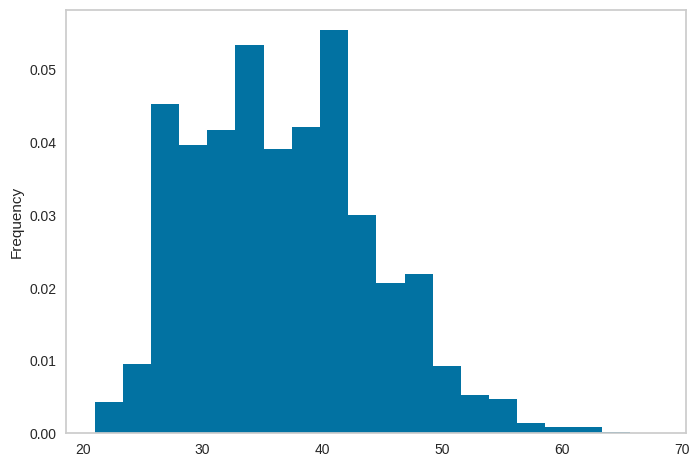

In [ ]:
# Converting Age into years from days
acc_rec_df['Age']=-(acc_rec_df['DAYS_BIRTH'])//365
print(acc_rec_df['Age'].value_counts(bins=10,normalize=True,sort=False))
acc_rec_df['Age'].plot(kind='hist',bins=20,density=True)

<Axes: ylabel='Frequency'>

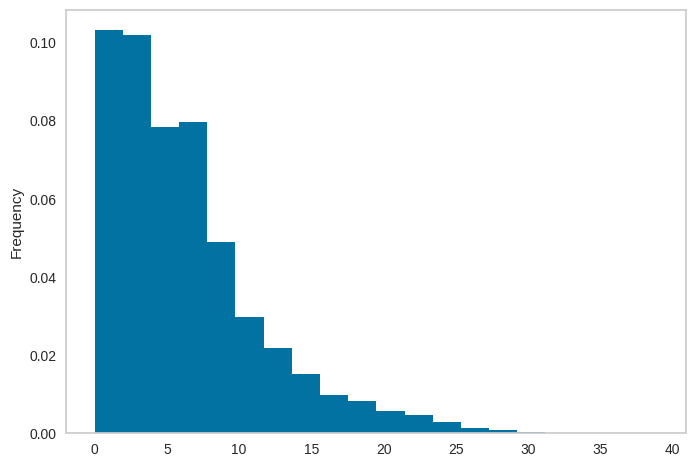

In [ ]:
acc_rec_df['work_yr']=-(acc_rec_df['DAYS_EMPLOYED'])//365
acc_rec_df[acc_rec_df['work_yr']<0] = np.nan # replace by na
acc_rec_df['DAYS_EMPLOYED']
acc_rec_df['work_yr'].fillna(acc_rec_df['work_yr'].mean(),inplace=True) #replace na by mean
acc_rec_df['work_yr'].plot(kind='hist',bins=20,density=True)

In [ ]:
# Cleaning Credit record dataset
cc_rec_df['Months from today'] = cc_rec_df['MONTHS_BALANCE']*-1
cc_rec_df = cc_rec_df.sort_values(['ID','Months from today'], ascending=True)
print(cc_rec_df.head(10))

cc_rec_df.value_counts('STATUS')



        ID  MONTHS_BALANCE STATUS  Months from today
0  5001711               0      X                  0
1  5001711              -1      0                  1
2  5001711              -2      0                  2
3  5001711              -3      0                  3
4  5001712               0      C                  0
5  5001712              -1      C                  1
6  5001712              -2      C                  2
7  5001712              -3      C                  3
8  5001712              -4      C                  4
9  5001712              -5      C                  5


,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


In [ ]:
#For the status of C,X, and 0 I will rename it into 0 which means good debt and for 1-5 will be renamed into 1 where it means bad debt
cc_rec_df['STATUS'] = cc_rec_df['STATUS'].replace(['C','X','0'],0)
cc_rec_df['STATUS'] = cc_rec_df['STATUS'].replace(['1','2','3','4','5'],1)
cc_rec_df.head()

cc_rec_group = cc_rec_df.groupby('ID').agg(max).reset_index()
cc_rec_group.head()

,ID,MONTHS_BALANCE,STATUS,Months from today
0,5001711,0,0,3
1,5001712,0,0,18
2,5001713,0,0,21
3,5001714,0,0,14
4,5001715,0,0,59


In [ ]:
#Merging datasets
df = acc_rec_df.join(cc_rec_group.set_index('ID'), on='ID', how='inner')
df.drop(['MONTHS_BALANCE', 'Months from today', 'DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1, inplace=True)

#checking for the df info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6071 entries, 29 to 434805
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   6071 non-null   float64
 1   CODE_GENDER          6071 non-null   float64
 2   FLAG_OWN_CAR         6071 non-null   float64
 3   FLAG_OWN_REALTY      6071 non-null   float64
 4   CNT_CHILDREN         6071 non-null   float64
 5   AMT_INCOME_TOTAL     6071 non-null   float64
 6   NAME_INCOME_TYPE     6071 non-null   float64
 7   NAME_EDUCATION_TYPE  6071 non-null   float64
 8   NAME_FAMILY_STATUS   6071 non-null   float64
 9   NAME_HOUSING_TYPE    6071 non-null   float64
 10  FLAG_MOBIL           6071 non-null   float64
 11  FLAG_WORK_PHONE      6071 non-null   float64
 12  FLAG_PHONE           6071 non-null   float64
 13  FLAG_EMAIL           6071 non-null   float64
 14  CNT_FAM_MEMBERS      6071 non-null   float64
 15  Age                  6071 non-null   flo

# Data analysis

In [ ]:
X = df.iloc[:,1:-1] # X value isinya semua variable kecuali labels / dependent variable kita Status (good/bad credit)
y = df.iloc[:,-1] # Y value isinya labels / dependent variable kita Status (good/bad credit)

In [ ]:
# Start Split testing for Training data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3)

In [ ]:
# Fit into a scaler for a more accurate model
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)



In [ ]:
# Solving oversampling because of the renaming on the status column in the coredit record to ensure ML model not overfit
from imblearn.over_sampling import SMOTE
oversample = SMOTE()
X_balanced, y_balanced = oversample.fit_resample(X_scaled, y_train)
X_test_balanced, y_test_balanced = oversample.fit_resample(X_test_scaled, y_test)

In [ ]:
# To check if the over sampling problem has been fixed
print(y_train.value_counts())
print(y_balanced.value_counts())
print(y_test.value_counts())
print(y_test_balanced.value_counts())

STATUS
0    3798
1     451
Name: count, dtype: int64
STATUS
0    3798
1    3798
Name: count, dtype: int64
STATUS
0    1598
1     224
Name: count, dtype: int64
STATUS
0    1598
1    1598
Name: count, dtype: int64


In [ ]:
# Now that the data has been processed and trained we can try multiple types of ML model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Neighbors Classifier': KNeighborsClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'Random Forest Classifier': RandomForestClassifier(),
    'XGBoost Classifier': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [ ]:
results_list = []
for model_name, model in models.items():
    # Train the model
    model.fit(X_balanced, y_balanced)

    # Make predictions
    y_pred = model.predict(X_test_balanced)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test_balanced, y_pred)
    report = classification_report(y_test_balanced, y_pred, output_dict=True)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']

   # Append results to the list
    results_list.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1_score
    })

# Display the results
results = pd.DataFrame(results_list)
print(results)

                      Model  Accuracy  Precision    Recall  F1 Score
0       Logistic Regression  0.530663   0.530669  0.530663  0.530641
1    K-Neighbors Classifier  0.703066   0.723857  0.703066  0.696008
2  Decision Tree Classifier  0.816959   0.831347  0.816959  0.814950
3  Random Forest Classifier  0.816959   0.833806  0.816959  0.814620
4        XGBoost Classifier  0.881727   0.886970  0.881727  0.881325


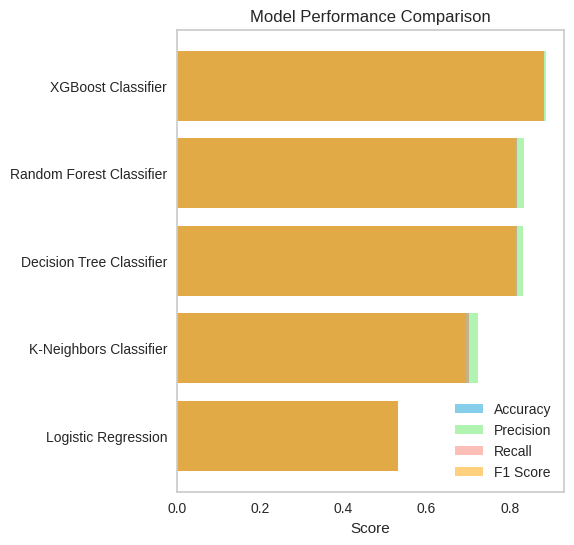

In [ ]:
# Visualize the results
plt.figure(figsize=(5, 6))

plt.barh(results['Model'], results['Accuracy'], color='skyblue', label='Accuracy')
plt.barh(results['Model'], results['Precision'], color='lightgreen', label='Precision', alpha=0.7)
plt.barh(results['Model'], results['Recall'], color='salmon', label='Recall', alpha=0.5)
plt.barh(results['Model'], results['F1 Score'], color='orange', label='F1 Score', alpha=0.5)

plt.xlabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

                Feature  Importance
15              work_yr    0.207146
14                  Age    0.189734
4      AMT_INCOME_TOTAL    0.181486
5      NAME_INCOME_TYPE    0.069766
6   NAME_EDUCATION_TYPE    0.066113
1          FLAG_OWN_CAR    0.042451
0           CODE_GENDER    0.039977
2       FLAG_OWN_REALTY    0.038103
11           FLAG_PHONE    0.036329
8     NAME_HOUSING_TYPE    0.035093
10      FLAG_WORK_PHONE    0.033500
7    NAME_FAMILY_STATUS    0.031479
12           FLAG_EMAIL    0.023328
3          CNT_CHILDREN    0.005495
9            FLAG_MOBIL    0.000000
13      CNT_FAM_MEMBERS    0.000000


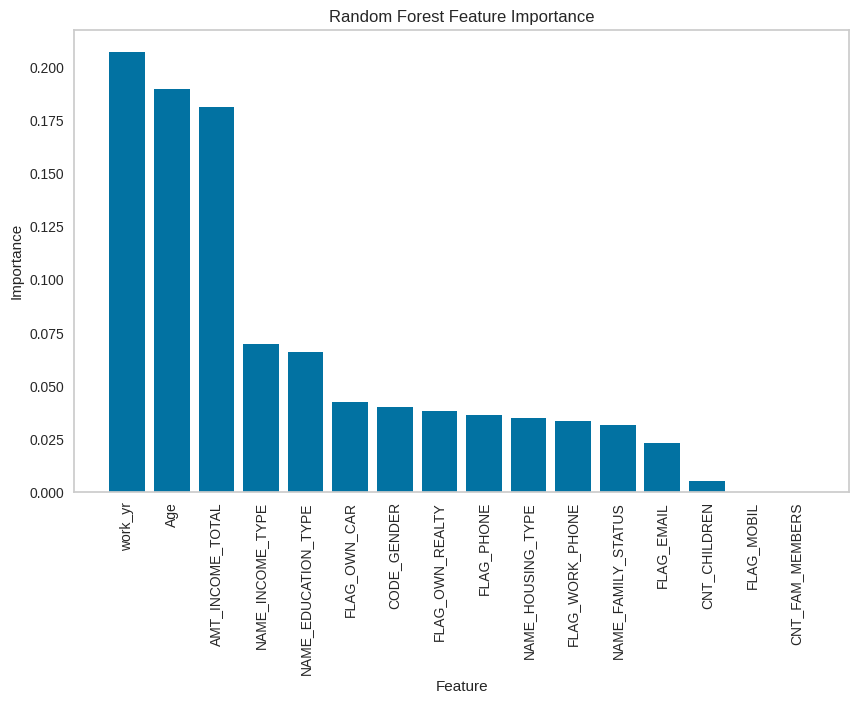

In [ ]:
# Getting Random forest results and also analysis
random_forest = models['Random Forest Classifier']
feature_importances = random_forest.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': X_balanced.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)
print(feature_imp_df)

plt.figure(figsize=(10, 6))
plt.bar(feature_imp_df['Feature'], feature_imp_df['Importance'])
plt.xticks(rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

In [ ]:
import sklearn.metrics as met
print(met.classification_report(y_test_balanced, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1598
           1       0.93      0.82      0.87      1598

    accuracy                           0.88      3196
   macro avg       0.89      0.88      0.88      3196
weighted avg       0.89      0.88      0.88      3196



In [ ]:
# Download final data used for Dashboard visualization
##from google.colab import files

##df.to_csv('final_data.csv', index=False)
##files.download('final_data.csv')